In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
results = pd.read_csv("../reports/baseline_predictions.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


C:\Users\user\AppData\Local\Temp\ipykernel_23020\682752381.py:1: DtypeWarning: Columns (0: promo_event) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../reports/baseline_predictions.csv")


In [3]:
results.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,promo_event,on_hand_units,on_order_units,lead_time_days,reorder_point,day,day_of_week,quarter,year,Predicted_Units_Sold
0,2024-01-01,SKU001,16,3814.08,238.38,0,Appliances,General,2023-01-01,173,...,NaN,171.0,95.0,13.0,71.0,1,0,1,2024,14.24
1,2024-01-01,SKU002,9,943.65,104.85,0,Furniture,General,2023-01-01,72,...,NaN,78.0,59.0,5.0,29.0,1,0,1,2024,10.11
2,2024-01-01,SKU003,14,4658.92,332.78,0,Furniture,General,2023-01-01,183,...,NaN,135.0,86.0,15.0,74.0,1,0,1,2024,12.40
3,2024-01-01,SKU004,11,2825.35,256.85,0,Furniture,General,2023-01-01,161,...,NaN,207.0,11.0,15.0,20.0,1,0,1,2024,10.72
4,2024-01-01,SKU005,12,575.40,47.95,0,Furniture,General,2023-01-01,33,...,NaN,155.0,68.0,6.0,49.0,1,0,1,2024,10.77


In [4]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 73000 entries, 0 to 72999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  73000 non-null  str    
 1   sku_id                73000 non-null  str    
 2   units_sold            73000 non-null  int64  
 3   revenue               73000 non-null  float64
 4   unit_price            73000 non-null  float64
 5   promo_flag            73000 non-null  int64  
 6   category              73000 non-null  str    
 7   subcategory           73000 non-null  str    
 8   launch_date           73000 non-null  str    
 9   unit_cost             73000 non-null  int64  
 10  list_price            73000 non-null  float64
 11  week                  73000 non-null  int64  
 12  month                 73000 non-null  int64  
 13  season                73000 non-null  str    
 14  is_holiday            73000 non-null  int64  
 15  promo_event           1600 non

In [5]:
results.isnull().sum()

date                        0
sku_id                      0
units_sold                  0
revenue                     0
unit_price                  0
promo_flag                  0
category                    0
subcategory                 0
launch_date                 0
unit_cost                   0
list_price                  0
week                        0
month                       0
season                      0
is_holiday                  0
promo_event             71400
on_hand_units           63400
on_order_units          63400
lead_time_days          63400
reorder_point           63400
day                         0
day_of_week                 0
quarter                     0
year                        0
Predicted_Units_Sold        0
dtype: int64

In [6]:
results["on_hand_units"] = results["on_hand_units"].fillna(0)
results["Predicted_Units_Sold"] = results["Predicted_Units_Sold"].fillna(0)

print("Missing Values Filled Successfully")

Missing Values Filled Successfully


In [7]:
results["Inventory_Gap"] = (
    results["on_hand_units"]
    -
    results["Predicted_Units_Sold"]
)

results.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,on_hand_units,on_order_units,lead_time_days,reorder_point,day,day_of_week,quarter,year,Predicted_Units_Sold,Inventory_Gap
0,2024-01-01,SKU001,16,3814.08,238.38,0,Appliances,General,2023-01-01,173,...,171.0,95.0,13.0,71.0,1,0,1,2024,14.24,156.76
1,2024-01-01,SKU002,9,943.65,104.85,0,Furniture,General,2023-01-01,72,...,78.0,59.0,5.0,29.0,1,0,1,2024,10.11,67.89
2,2024-01-01,SKU003,14,4658.92,332.78,0,Furniture,General,2023-01-01,183,...,135.0,86.0,15.0,74.0,1,0,1,2024,12.40,122.60
3,2024-01-01,SKU004,11,2825.35,256.85,0,Furniture,General,2023-01-01,161,...,207.0,11.0,15.0,20.0,1,0,1,2024,10.72,196.28
4,2024-01-01,SKU005,12,575.40,47.95,0,Furniture,General,2023-01-01,33,...,155.0,68.0,6.0,49.0,1,0,1,2024,10.77,144.23


In [8]:
results["Inventory_Coverage"] = (
    results["on_hand_units"]
    /
    (results["Predicted_Units_Sold"] + 1)
)

results.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,on_order_units,lead_time_days,reorder_point,day,day_of_week,quarter,year,Predicted_Units_Sold,Inventory_Gap,Inventory_Coverage
0,2024-01-01,SKU001,16,3814.08,238.38,0,Appliances,General,2023-01-01,173,...,95.0,13.0,71.0,1,0,1,2024,14.24,156.76,11.220472
1,2024-01-01,SKU002,9,943.65,104.85,0,Furniture,General,2023-01-01,72,...,59.0,5.0,29.0,1,0,1,2024,10.11,67.89,7.020702
2,2024-01-01,SKU003,14,4658.92,332.78,0,Furniture,General,2023-01-01,183,...,86.0,15.0,74.0,1,0,1,2024,12.40,122.60,10.074627
3,2024-01-01,SKU004,11,2825.35,256.85,0,Furniture,General,2023-01-01,161,...,11.0,15.0,20.0,1,0,1,2024,10.72,196.28,17.662116
4,2024-01-01,SKU005,12,575.40,47.95,0,Furniture,General,2023-01-01,33,...,68.0,6.0,49.0,1,0,1,2024,10.77,144.23,13.169074


In [9]:
results["Risk_Score"] = np.where(

    results["Inventory_Gap"] < 0,

    100,

    (1 / (results["Inventory_Coverage"] + 1)) * 100

)

results.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,lead_time_days,reorder_point,day,day_of_week,quarter,year,Predicted_Units_Sold,Inventory_Gap,Inventory_Coverage,Risk_Score
0,2024-01-01,SKU001,16,3814.08,238.38,0,Appliances,General,2023-01-01,173,...,13.0,71.0,1,0,1,2024,14.24,156.76,11.220472,8.182990
1,2024-01-01,SKU002,9,943.65,104.85,0,Furniture,General,2023-01-01,72,...,5.0,29.0,1,0,1,2024,10.11,67.89,7.020702,12.467737
2,2024-01-01,SKU003,14,4658.92,332.78,0,Furniture,General,2023-01-01,183,...,15.0,74.0,1,0,1,2024,12.40,122.60,10.074627,9.029650
3,2024-01-01,SKU004,11,2825.35,256.85,0,Furniture,General,2023-01-01,161,...,15.0,20.0,1,0,1,2024,10.72,196.28,17.662116,5.358449
4,2024-01-01,SKU005,12,575.40,47.95,0,Furniture,General,2023-01-01,33,...,6.0,49.0,1,0,1,2024,10.77,144.23,13.169074,7.057624


In [10]:
def assign_risk(score):

    if score >= 70:
        return "High"

    elif score >= 40:
        return "Medium"

    else:
        return "Low"

In [11]:
results["Risk_Level"] = results["Risk_Score"].apply(assign_risk)

results.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,reorder_point,day,day_of_week,quarter,year,Predicted_Units_Sold,Inventory_Gap,Inventory_Coverage,Risk_Score,Risk_Level
0,2024-01-01,SKU001,16,3814.08,238.38,0,Appliances,General,2023-01-01,173,...,71.0,1,0,1,2024,14.24,156.76,11.220472,8.182990,Low
1,2024-01-01,SKU002,9,943.65,104.85,0,Furniture,General,2023-01-01,72,...,29.0,1,0,1,2024,10.11,67.89,7.020702,12.467737,Low
2,2024-01-01,SKU003,14,4658.92,332.78,0,Furniture,General,2023-01-01,183,...,74.0,1,0,1,2024,12.40,122.60,10.074627,9.029650,Low
3,2024-01-01,SKU004,11,2825.35,256.85,0,Furniture,General,2023-01-01,161,...,20.0,1,0,1,2024,10.72,196.28,17.662116,5.358449,Low
4,2024-01-01,SKU005,12,575.40,47.95,0,Furniture,General,2023-01-01,33,...,49.0,1,0,1,2024,10.77,144.23,13.169074,7.057624,Low


In [12]:
results["Risk_Level"].value_counts()

Risk_Level
High      63400
Low        9549
Medium       51
Name: count, dtype: int64

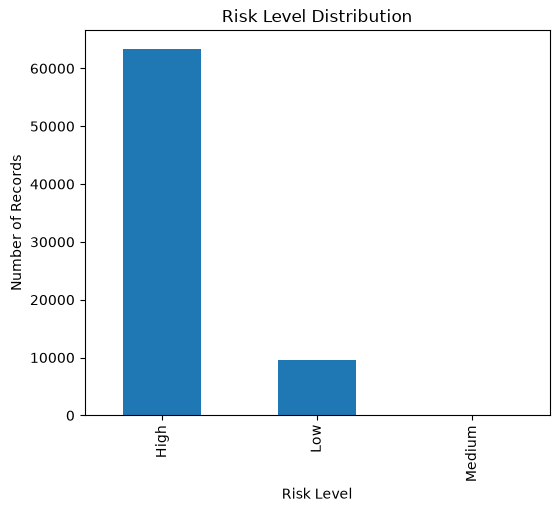

In [13]:
results["Risk_Level"].value_counts().plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Risk Level Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Number of Records")

plt.show()

In [14]:
high_risk = results[
    results["Risk_Level"] == "High"
]

high_risk.head(20)

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,reorder_point,day,day_of_week,quarter,year,Predicted_Units_Sold,Inventory_Gap,Inventory_Coverage,Risk_Score,Risk_Level
200,2024-01-02,SKU001,17,4052.46,238.38,0,Appliances,General,2023-01-01,173,...,NaN,2,1,1,2024,14.24,-14.24,0.0,100.0,High
201,2024-01-02,SKU002,16,1677.60,104.85,0,Furniture,General,2023-01-01,72,...,NaN,2,1,1,2024,14.08,-14.08,0.0,100.0,High
202,2024-01-02,SKU003,7,2329.46,332.78,0,Furniture,General,2023-01-01,183,...,NaN,2,1,1,2024,8.79,-8.79,0.0,100.0,High
203,2024-01-02,SKU004,8,2054.80,256.85,0,Furniture,General,2023-01-01,161,...,NaN,2,1,1,2024,11.04,-11.04,0.0,100.0,High
204,2024-01-02,SKU005,13,623.35,47.95,0,Furniture,General,2023-01-01,33,...,NaN,2,1,1,2024,12.20,-12.20,0.0,100.0,High
205,2024-01-02,SKU006,13,2862.60,220.20,0,Kitchen,General,2023-01-01,153,...,NaN,2,1,1,2024,11.65,-11.65,0.0,100.0,High
206,2024-01-02,SKU007,19,2024.45,106.55,0,Appliances,General,2023-01-01,66,...,NaN,2,1,1,2024,15.03,-15.03,0.0,100.0,High
207,2024-01-02,SKU008,11,221.54,20.14,0,Decor,General,2023-01-01,11,...,NaN,2,1,1,2024,11.72,-11.72,0.0,100.0,High
208,2024-01-02,SKU009,8,2400.16,300.02,0,Appliances,General,2023-01-01,188,...,NaN,2,1,1,2024,9.54,-9.54,0.0,100.0,High
209,2024-01-02,SKU010,6,426.54,71.09,0,Appliances,General,2023-01-01,49,...,NaN,2,1,1,2024,8.02,-8.02,0.0,100.0,High


In [15]:
results.to_csv(
    "../reports/risk_scoring.csv",
    index=False
)

print("Risk Scoring Dataset Saved Successfully")

Risk Scoring Dataset Saved Successfully


In [16]:
print("="*60)
print("RISK SCORING COMPLETED SUCCESSFULLY")
print("="*60)

print()

print("High Risk Products :", (results["Risk_Level"]=="High").sum())
print("Medium Risk Products :", (results["Risk_Level"]=="Medium").sum())
print("Low Risk Products :", (results["Risk_Level"]=="Low").sum())

RISK SCORING COMPLETED SUCCESSFULLY

High Risk Products : 63400
Medium Risk Products : 51
Low Risk Products : 9549
